<a href="https://colab.research.google.com/github/saltyyboii/landslide-risk-assessment/blob/main/Mountain_Hazard_Review_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Based Multi-Hazard Prediction System

### PBL-1 Project

This project uses machine learning techniques to analyze historical landslide events
and environmental factors such as rainfall and elevation to estimate landslide risk
in mountain regions.

## 1. Problem Statement

Landslides are one of the major natural hazards in mountainous regions such as Nepal.
They can cause loss of life, damage to infrastructure, and disruption of transportation
and communities.

Traditional assessment of landslide risk mainly depends on historical records and
manual analysis. However, environmental factors such as rainfall, elevation, latitude,
and longitude can be used with machine learning techniques to identify patterns
associated with landslide occurrence.

The objective of this project is to develop a machine learning-based system that:

- Analyzes historical landslide events.
- Explores important environmental patterns associated with landslides.
- Implements regression and classification techniques from the Unit-2 syllabus.
- Compares different machine learning models using appropriate evaluation metrics.
- Estimates the probability and risk level of landslide occurrence for a given location
  using environmental features.

In [1]:
print("Hello Mountain Hazard Project!")

Hello Mountain Hazard Project!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/content/landslide.csv")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
df.head()

,source_name,source_link,event_id,event_date,event_time,event_title,event_description,location_description,location_accuracy,landslide_category,...,country_code,admin_division_name,admin_division_population,gazeteer_closest_point,gazeteer_distance,submitted_date,created_date,last_edited_date,longitude,latitude
0,AGU,https://blogs.agu.org/landslideblog/2008/10/14...,684,08/01/2008 12:00:00 AM,NaN,"Sigou Village, Loufan County, Shanxi Province","occurred early in morning, 11 villagers buried...","Sigou Village, Loufan County, Shanxi Province",unknown,landslide,...,CN,Shaanxi,0.0,Jingyang,41.02145,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,107.4500,32.5625
1,Oregonian,http://www.oregonlive.com/news/index.ssf/2009/...,956,01/02/2009 02:00:00 AM,NaN,"Lake Oswego, Oregon",Hours of heavy rain are to blame for an overni...,"Lake Oswego, Oregon",5km,mudslide,...,US,Oregon,36619.0,Lake Oswego,0.60342,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,-122.6630,45.4200
2,CBS News,https://www.cbsnews.com/news/dozens-missing-af...,973,01/19/2007 12:00:00 AM,NaN,"San Ramon district, 195 miles northeast of the...",(CBS/AP) At least 10 people died and as many a...,"San Ramon district, 195 miles northeast of the...",10km,landslide,...,PE,Junín,14708.0,San Ramón,0.85548,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,-75.3587,-11.1295
3,Reuters,https://in.reuters.com/article/idINIndia-41450...,1067,07/31/2009 12:00:00 AM,NaN,Dailekh district,"One person was killed in Dailekh district, pol...",Dailekh district,unknown,landslide,...,NP,Mid Western,20908.0,Dailekh,0.75395,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,81.7080,28.8378
4,The Freeman,http://www.philstar.com/cebu-news/621414/lands...,2603,10/16/2010 12:00:00 PM,NaN,sitio Bakilid in barangay Lahug,Another landslide in sitio Bakilid in barangay...,sitio Bakilid in barangay Lahug,5km,landslide,...,PH,Central Visayas,798634.0,Cebu City,2.02204,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,123.8978,10.3336


In [6]:
df.columns.tolist()

['source_name',
 'source_link',
 'event_id',
 'event_date',
 'event_time',
 'event_title',
 'event_description',
 'location_description',
 'location_accuracy',
 'landslide_category',
 'landslide_trigger',
 'landslide_size',
 'landslide_setting',
 'fatality_count',
 'injury_count',
 'storm_name',
 'photo_link',
 'notes',
 'event_import_source',
 'event_import_id',
 'country_name',
 'country_code',
 'admin_division_name',
 'admin_division_population',
 'gazeteer_closest_point',
 'gazeteer_distance',
 'submitted_date',
 'created_date',
 'last_edited_date',
 'longitude',
 'latitude']

In [7]:
df["landslide_trigger"].value_counts()

,count
landslide_trigger,
downpour,4680
rain,2592
unknown,1691
continuous_rain,748
tropical_cyclone,561
snowfall_snowmelt,135
monsoon,129
mining,93
earthquake,89


In [8]:
df["landslide_category"].value_counts()

,count
landslide_category,
landslide,7648
mudslide,2100
rock_fall,671
complex,232
debris_flow,194
other,68
unknown,38
riverbank_collapse,37
snow_avalanche,15


In [9]:
df["country_code"].value_counts().head(20)

,count
country_code,
US,2992
IN,1265
PH,675
NP,481
CN,426
ID,355
GB,229
BR,214
CA,174


In [10]:
nepal = df[df["country_code"] == "NP"]

print(nepal.shape)

(481, 31)


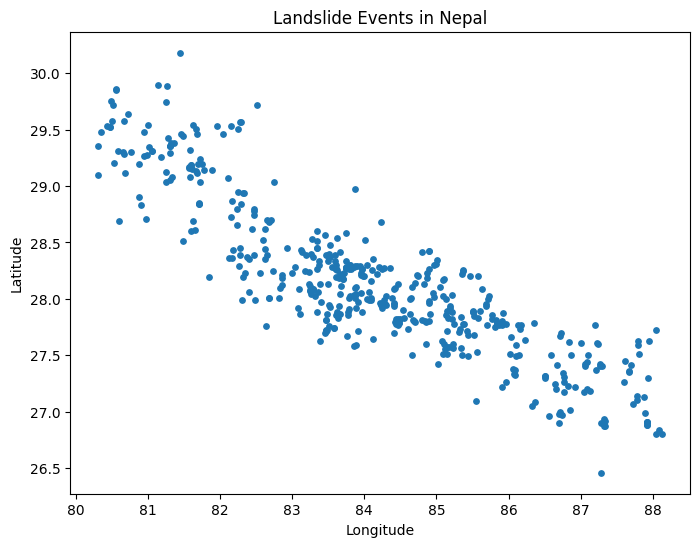

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(
    nepal["longitude"],
    nepal["latitude"],
    s=15
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Landslide Events in Nepal")

plt.show()

In [12]:
df["landslide_trigger"].value_counts()

,count
landslide_trigger,
downpour,4680
rain,2592
unknown,1691
continuous_rain,748
tropical_cyclone,561
snowfall_snowmelt,135
monsoon,129
mining,93
earthquake,89


In [13]:
df["landslide_category"].value_counts()

,count
landslide_category,
landslide,7648
mudslide,2100
rock_fall,671
complex,232
debris_flow,194
other,68
unknown,38
riverbank_collapse,37
snow_avalanche,15


In [14]:
nepal = df[df["country_code"] == "NP"]
print(nepal.shape)

(481, 31)


In [15]:
nepal = df[df["country_code"] == "NP"].copy()

In [16]:
nepal[["event_date", "latitude", "longitude"]].head()

,event_date,latitude,longitude
3,07/31/2009 12:00:00 AM,28.8378,81.7080
39,07/02/2009 03:00:00 AM,28.2039,83.9806
40,07/02/2009 12:00:00 AM,27.9447,84.2279
46,07/27/2009 12:00:00 AM,28.0000,85.7100
47,07/31/2009 12:00:00 AM,28.1046,83.8791


In [17]:
nepal["event_date"] = pd.to_datetime(
    nepal["event_date"],
    errors="coerce"
)

/tmp/ipykernel_6163/941996008.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  nepal["event_date"] = pd.to_datetime(


In [18]:
nepal["event_date"] = pd.to_datetime(
    nepal["event_date"],
    format="%m/%d/%Y %I:%M:%S %p",
    errors="coerce"
)

In [19]:
nepal[["event_date", "latitude", "longitude"]].head()

,event_date,latitude,longitude
3,2009-07-31 00:00:00,28.8378,81.7080
39,2009-07-02 03:00:00,28.2039,83.9806
40,2009-07-02 00:00:00,27.9447,84.2279
46,2009-07-27 00:00:00,28.0000,85.7100
47,2009-07-31 00:00:00,28.1046,83.8791


In [20]:
!pip install -q earthengine-api geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 54.3 MB/s eta 0:00:00


In [21]:
import ee
import geemap

In [23]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 11033
Number of columns: 31


In [74]:
# Step 1: Check the Nepal landslide data
# We will use the location and date of past events
# to connect environmental data such as rainfall later.

print("Number of Nepal landslide events:", len(nepal))

print("\nAvailable columns:")
print(nepal.columns.tolist())

print("\nDate range:")
print(nepal["event_date"].min(), "to", nepal["event_date"].max())

print("\nLatitude range:")
print(nepal["latitude"].min(), "to", nepal["latitude"].max())

print("\nLongitude range:")
print(nepal["longitude"].min(), "to", nepal["longitude"].max())

Number of Nepal landslide events: 481

Available columns:
['source_name', 'source_link', 'event_id', 'event_date', 'event_time', 'event_title', 'event_description', 'location_description', 'location_accuracy', 'landslide_category', 'landslide_trigger', 'landslide_size', 'landslide_setting', 'fatality_count', 'injury_count', 'storm_name', 'photo_link', 'notes', 'event_import_source', 'event_import_id', 'country_name', 'country_code', 'admin_division_name', 'admin_division_population', 'gazeteer_closest_point', 'gazeteer_distance', 'submitted_date', 'created_date', 'last_edited_date', 'longitude', 'latitude', 'year']

Date range:
2007-03-21 00:00:00 to 2016-10-13 00:00:00

Latitude range:
26.4596 to 30.1818

Longitude range:
80.3109 to 88.125


In [75]:
# Step 2: Create a clean dataset containing
# the location and date of each historical landslide

rainfall_data = nepal[
    ["event_date", "latitude", "longitude", "landslide_category"]
].copy()

# Remove records with missing location or date
rainfall_data = rainfall_data.dropna(
    subset=["event_date", "latitude", "longitude"]
)

print("Records available for environmental data:", len(rainfall_data))
display(rainfall_data.head())

Records available for environmental data: 481


,event_date,latitude,longitude,landslide_category
3,2009-07-31 00:00:00,28.8378,81.7080,landslide
39,2009-07-02 03:00:00,28.2039,83.9806,landslide
40,2009-07-02 00:00:00,27.9447,84.2279,landslide
46,2009-07-27 00:00:00,28.0000,85.7100,landslide
47,2009-07-31 00:00:00,28.1046,83.8791,landslide


In [76]:
# Step 3: Import libraries for getting historical rainfall data

import requests
import time

print("Libraries ready.")

Libraries ready.


In [77]:
# Step 4: Function to retrieve rainfall for one location and date

def get_rainfall(latitude, longitude, date):

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": date,
        "end_date": date,
        "daily": "rain_sum",
        "timezone": "auto"
    }

    response = requests.get(url, params=params)
    data = response.json()

    # Extract rainfall value
    rainfall = data["daily"]["rain_sum"][0]

    return rainfall

print("Rainfall function created.")

Rainfall function created.


## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution
of landslide events, their major triggers, variation over time, and
relationships between environmental factors.

The analysis helps identify patterns and features that may be useful
for machine learning-based landslide prediction.

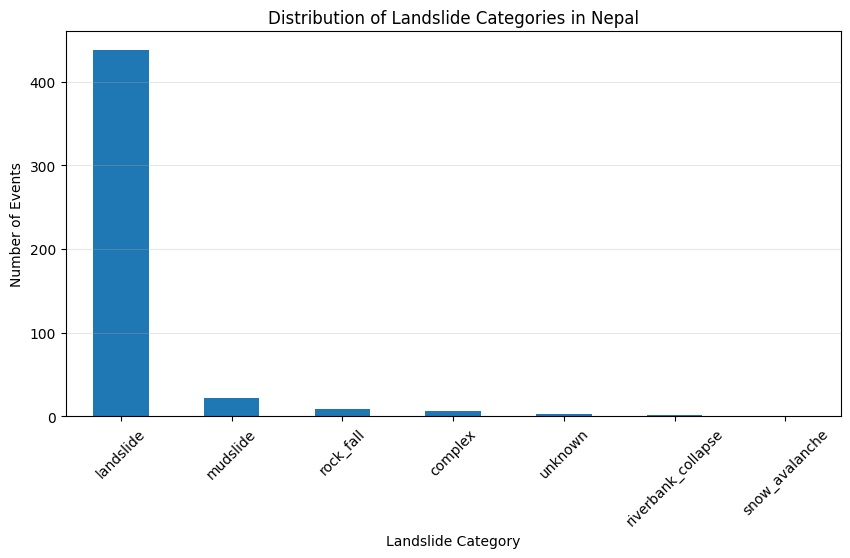

In [103]:
# EDA 1: Distribution of landslide categories in Nepal

plt.figure(figsize=(10, 5))

nepal["landslide_category"].value_counts().plot(kind="bar")

plt.title("Distribution of Landslide Categories in Nepal")
plt.xlabel("Landslide Category")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

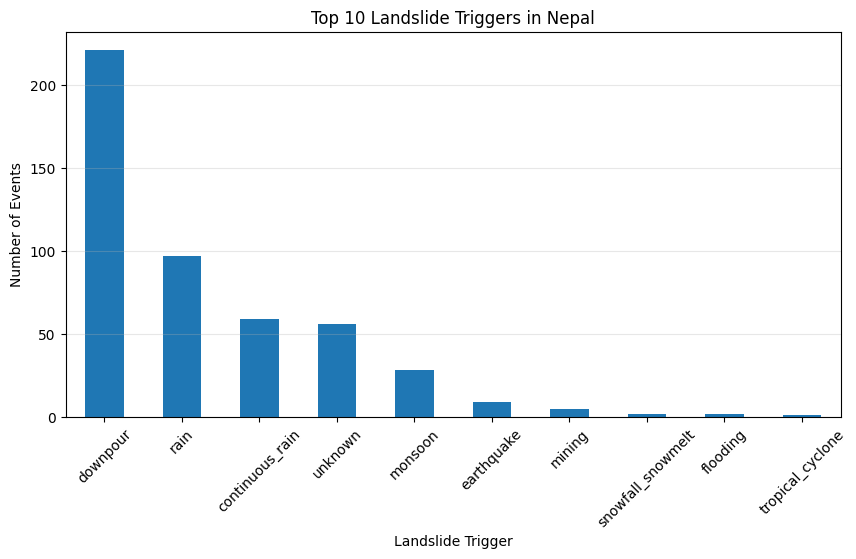

In [104]:
# EDA 2: Top 10 landslide triggers in Nepal

plt.figure(figsize=(10, 5))

nepal["landslide_trigger"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Landslide Triggers in Nepal")
plt.xlabel("Landslide Trigger")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

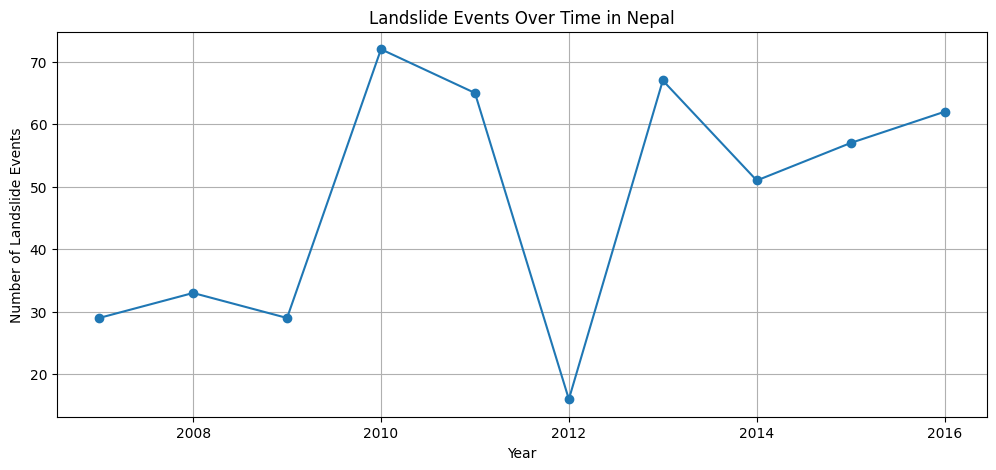

In [105]:
# EDA 3: Number of landslide events by year

nepal["year"] = nepal["event_date"].dt.year

yearly_events = nepal["year"].value_counts().sort_index()

plt.figure(figsize=(12, 5))

plt.plot(
    yearly_events.index,
    yearly_events.values,
    marker="o"
)

plt.title("Landslide Events Over Time in Nepal")
plt.xlabel("Year")
plt.ylabel("Number of Landslide Events")
plt.grid(True)

plt.show()

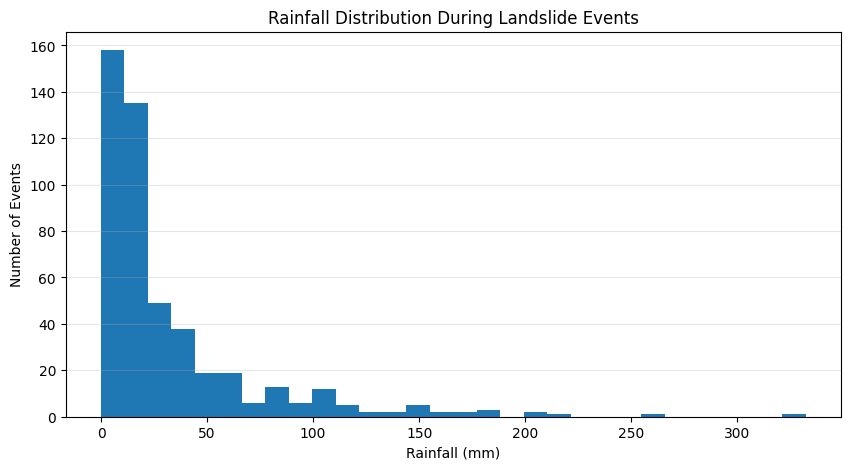

In [106]:
# EDA 4: Rainfall distribution during historical landslide events

plt.figure(figsize=(10, 5))

plt.hist(
    rainfall_data["rainfall_mm"],
    bins=30
)

plt.title("Rainfall Distribution During Landslide Events")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Number of Events")
plt.grid(axis="y", alpha=0.3)

plt.show()

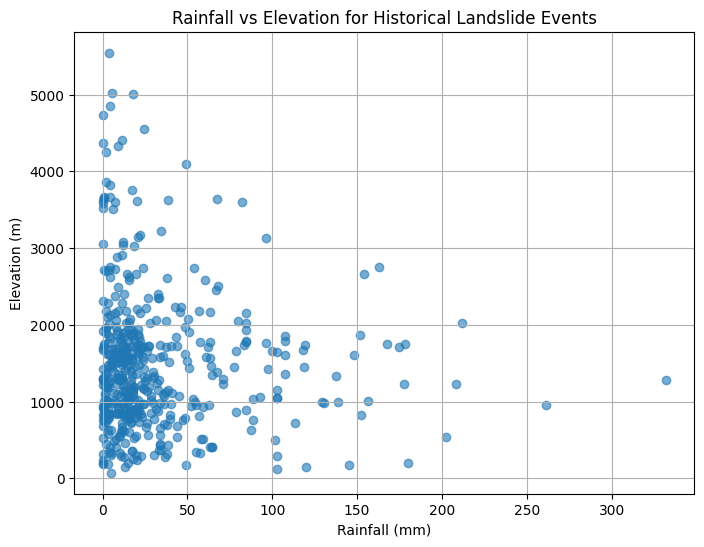

In [107]:
# EDA 5: Relationship between rainfall and elevation

plt.figure(figsize=(8, 6))

plt.scatter(
    rainfall_data["rainfall_mm"],
    rainfall_data["elevation_m"],
    alpha=0.6
)

plt.title("Rainfall vs Elevation for Historical Landslide Events")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Elevation (m)")
plt.grid(True)

plt.show()

In [78]:
# Step 5: Test rainfall retrieval for the first landslide

test_row = rainfall_data.iloc[0]

rainfall = get_rainfall(
    test_row["latitude"],
    test_row["longitude"],
    test_row["event_date"].strftime("%Y-%m-%d")
)

print("Date:", test_row["event_date"].date())
print("Latitude:", test_row["latitude"])
print("Longitude:", test_row["longitude"])
print("Rainfall:", rainfall, "mm")

Date: 2009-07-31
Latitude: 28.8378
Longitude: 81.708
Rainfall: 2.1 mm


In [79]:
# Step 6: Retrieve historical rainfall for all landslide events

rainfall_values = []

for index, row in rainfall_data.iterrows():

    rainfall = get_rainfall(
        row["latitude"],
        row["longitude"],
        row["event_date"].strftime("%Y-%m-%d")
    )

    rainfall_values.append(rainfall)

    # Small delay to avoid sending requests too quickly
    time.sleep(0.2)

rainfall_data["rainfall_mm"] = rainfall_values

print("Rainfall data added successfully.")
display(rainfall_data.head())

Rainfall data added successfully.


,event_date,latitude,longitude,landslide_category,rainfall_mm
3,2009-07-31 00:00:00,28.8378,81.7080,landslide,2.1
39,2009-07-02 03:00:00,28.2039,83.9806,landslide,39.5
40,2009-07-02 00:00:00,27.9447,84.2279,landslide,19.9
46,2009-07-27 00:00:00,28.0000,85.7100,landslide,96.1
47,2009-07-31 00:00:00,28.1046,83.8791,landslide,20.6


In [80]:
# Step 7: Check the rainfall data

print("Rainfall statistics:")
print(rainfall_data["rainfall_mm"].describe())

print("\nMissing rainfall values:")
print(rainfall_data["rainfall_mm"].isnull().sum())

print("\nMaximum rainfall:")
print(rainfall_data["rainfall_mm"].max(), "mm")

print("\nMinimum rainfall:")
print(rainfall_data["rainfall_mm"].min(), "mm")

Rainfall statistics:
count    481.000000
mean      31.785447
std       41.602257
min        0.000000
25%        7.800000
50%       17.100000
75%       37.300000
max      332.200000
Name: rainfall_mm, dtype: float64

Missing rainfall values:
0

Maximum rainfall:
332.2 mm

Minimum rainfall:
0.0 mm


In [81]:
# Step 8: Install the elevation data library

!pip install -q elevation

print("Elevation library installed successfully.")

Elevation library installed successfully.


In [83]:
# Step 9: Test elevation retrieval for one landslide location

import requests

def get_elevation(latitude, longitude):
    # Open-Meteo elevation API
    url = "https://api.open-meteo.com/v1/elevation"

    params = {
        "latitude": latitude,
        "longitude": longitude
    }

    response = requests.get(url, params=params)
    data = response.json()

    # Return elevation in meters
    return data["elevation"][0]


# Test with the first landslide
test_row = rainfall_data.iloc[0]

test_elevation = get_elevation(
    test_row["latitude"],
    test_row["longitude"]
)

print("Latitude:", test_row["latitude"])
print("Longitude:", test_row["longitude"])
print("Elevation:", test_elevation, "meters")

Latitude: 28.8378
Longitude: 81.708
Elevation: 1370.0 meters


In [85]:
# Step 9: Get elevation for all landslide locations in batches

import requests
import time

def get_elevation_batch(latitudes, longitudes):
    url = "https://api.open-meteo.com/v1/elevation"

    params = {
        "latitude": ",".join(map(str, latitudes)),
        "longitude": ",".join(map(str, longitudes))
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    return response.json()["elevation"]


# Store elevation values
elevation_values = []

# Process 50 locations at a time
batch_size = 50

for start in range(0, len(rainfall_data), batch_size):

    end = min(start + batch_size, len(rainfall_data))

    batch = rainfall_data.iloc[start:end]

    elevations = get_elevation_batch(
        batch["latitude"].tolist(),
        batch["longitude"].tolist()
    )

    elevation_values.extend(elevations)

    print(f"Processed {end}/{len(rainfall_data)} locations")

    time.sleep(0.5)


# Add elevation to our dataset
rainfall_data["elevation_m"] = elevation_values

print("\nElevation data added successfully!")

display(
    rainfall_data[
        ["latitude", "longitude", "rainfall_mm", "elevation_m"]
    ].head()
)

Processed 50/481 locations
Processed 100/481 locations
Processed 150/481 locations
Processed 200/481 locations
Processed 250/481 locations
Processed 300/481 locations
Processed 350/481 locations
Processed 400/481 locations
Processed 450/481 locations
Processed 481/481 locations

Elevation data added successfully!


,latitude,longitude,rainfall_mm,elevation_m
3,28.8378,81.7080,2.1,1370.0
39,28.2039,83.9806,39.5,829.0
40,27.9447,84.2279,19.9,556.0
46,28.0000,85.7100,96.1,3137.0
47,28.1046,83.8791,20.6,834.0


In [86]:
# Step 10: Create the environmental ML dataset

# Select the features we currently have
prediction_data = rainfall_data[
    [
        "event_date",
        "latitude",
        "longitude",
        "rainfall_mm",
        "elevation_m",
        "landslide_category"
    ]
].copy()

# Remove any missing values
prediction_data = prediction_data.dropna()

print("Prediction dataset shape:", prediction_data.shape)

display(prediction_data.head())

Prediction dataset shape: (481, 6)


,event_date,latitude,longitude,rainfall_mm,elevation_m,landslide_category
3,2009-07-31 00:00:00,28.8378,81.7080,2.1,1370.0,landslide
39,2009-07-02 03:00:00,28.2039,83.9806,39.5,829.0,landslide
40,2009-07-02 00:00:00,27.9447,84.2279,19.9,556.0,landslide
46,2009-07-27 00:00:00,28.0000,85.7100,96.1,3137.0,landslide
47,2009-07-31 00:00:00,28.1046,83.8791,20.6,834.0,landslide


In [87]:
# Step 11: Create background (non-landslide) locations
# We will randomly generate locations within Nepal that are
# different from the historical landslide locations.
# These will later represent potential non-landslide locations.

import numpy as np

np.random.seed(42)

# Nepal approximate geographical boundaries
min_lat = 26.4
max_lat = 30.2
min_lon = 80.0
max_lon = 88.2

# Generate 481 random background locations
n_background = len(prediction_data)

background_data = pd.DataFrame({
    "latitude": np.random.uniform(min_lat, max_lat, n_background),
    "longitude": np.random.uniform(min_lon, max_lon, n_background)
})

# Label:
# 1 = historical landslide location
# 0 = background / non-event location
prediction_data["landslide_occurrence"] = 1
background_data["landslide_occurrence"] = 0

print("Historical landslide samples:", len(prediction_data))
print("Background samples:", len(background_data))

display(background_data.head())

Historical landslide samples: 481
Background samples: 481


,latitude,longitude,landslide_occurrence
0,27.823252,85.705139,0
1,30.012714,83.727237,0
2,29.181577,85.145976,0
3,28.674902,84.791377,0
4,26.992871,87.389496,0


In [88]:
# Step 12: Get rainfall for the background locations
# Background locations do not have landslide event dates,
# so we use one common historical date for comparison.

import requests
import time

reference_date = "2016-07-15"

def get_rainfall_batch(latitudes, longitudes, date):
    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": ",".join(map(str, latitudes)),
        "longitude": ",".join(map(str, longitudes)),
        "start_date": date,
        "end_date": date,
        "daily": "rain_sum",
        "timezone": "auto"
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    data = response.json()

    # Open-Meteo returns a list for multiple locations
    if isinstance(data, list):
        return [item["daily"]["rain_sum"][0] for item in data]

    return [data["daily"]["rain_sum"][0]]


background_rainfall = []

batch_size = 50

for start in range(0, len(background_data), batch_size):

    end = min(start + batch_size, len(background_data))

    batch = background_data.iloc[start:end]

    rainfall = get_rainfall_batch(
        batch["latitude"].tolist(),
        batch["longitude"].tolist(),
        reference_date
    )

    background_rainfall.extend(rainfall)

    print(f"Processed {end}/{len(background_data)} background locations")

    time.sleep(0.5)


background_data["rainfall_mm"] = background_rainfall

print("\nBackground rainfall data added successfully!")

display(background_data.head())

Processed 50/481 background locations
Processed 100/481 background locations
Processed 150/481 background locations
Processed 200/481 background locations
Processed 250/481 background locations
Processed 300/481 background locations
Processed 350/481 background locations
Processed 400/481 background locations
Processed 450/481 background locations
Processed 481/481 background locations

Background rainfall data added successfully!


,latitude,longitude,landslide_occurrence,rainfall_mm
0,27.823252,85.705139,0,40.3
1,30.012714,83.727237,0,7.7
2,29.181577,85.145976,0,2.3
3,28.674902,84.791377,0,4.5
4,26.992871,87.389496,0,9.9


In [90]:
# Step 13 (fixed): Get elevation for background locations
# We use smaller batches and retry automatically if the API temporarily fails.

import requests
import time

def get_elevation_batch(latitudes, longitudes):
    url = "https://api.open-meteo.com/v1/elevation"

    params = {
        "latitude": ",".join(map(str, latitudes)),
        "longitude": ",".join(map(str, longitudes))
    }

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()

    return response.json()["elevation"]


# Start again with a clean list
background_elevation = []

# Smaller batches are more reliable
batch_size = 20

for start in range(0, len(background_data), batch_size):

    end = min(start + batch_size, len(background_data))
    batch = background_data.iloc[start:end]

    # Retry up to 3 times if the API fails
    success = False

    for attempt in range(3):

        try:
            elevations = get_elevation_batch(
                batch["latitude"].tolist(),
                batch["longitude"].tolist()
            )

            background_elevation.extend(elevations)

            print(f"Processed {end}/{len(background_data)} locations")

            success = True
            break

        except requests.exceptions.HTTPError as e:

            print(
                f"API error for {start}-{end}. "
                f"Retry {attempt + 1}/3..."
            )

            time.sleep(2)

    # Stop if a batch still fails after 3 attempts
    if not success:
        raise Exception(
            f"Failed to retrieve elevation for locations "
            f"{start} to {end}."
        )

    time.sleep(0.5)


# Add elevation to the dataset
background_data["elevation_m"] = background_elevation

print("\nElevation data added successfully!")

display(
    background_data[
        [
            "latitude",
            "longitude",
            "rainfall_mm",
            "elevation_m",
            "landslide_occurrence"
        ]
    ].head()
)

Processed 20/481 locations
Processed 40/481 locations
Processed 60/481 locations
Processed 80/481 locations
Processed 100/481 locations
Processed 120/481 locations


ReadTimeout: HTTPSConnectionPool(host='api.open-meteo.com', port=443): Read timed out. (read timeout=30)

In [91]:
# Step 15A: Check whether background elevation data was completed

print("Background rows:", len(background_data))

print("\nMissing elevation values:")
print(background_data["elevation_m"].isna().sum())

print("\nMissing rainfall values:")
print(background_data["rainfall_mm"].isna().sum())

Background rows: 481

Missing elevation values:


KeyError: 'elevation_m'

In [92]:
# Step 15A: Safely retrieve missing background elevations
# Results are saved directly into background_data after each batch.

import requests
import time
import numpy as np

# Create the column first
if "elevation_m" not in background_data.columns:
    background_data["elevation_m"] = np.nan


def get_elevation_batch(latitudes, longitudes):

    url = "https://api.open-meteo.com/v1/elevation"

    params = {
        "latitude": ",".join(map(str, latitudes)),
        "longitude": ",".join(map(str, longitudes))
    }

    response = requests.get(
        url,
        params=params,
        timeout=60
    )

    response.raise_for_status()

    return response.json()["elevation"]


# Find locations that still need elevation
missing_indices = background_data[
    background_data["elevation_m"].isna()
].index.tolist()

print("Locations needing elevation:", len(missing_indices))

batch_size = 10

for start in range(0, len(missing_indices), batch_size):

    batch_indices = missing_indices[start:start + batch_size]

    batch = background_data.loc[batch_indices]

    success = False

    for attempt in range(3):

        try:

            elevations = get_elevation_batch(
                batch["latitude"].tolist(),
                batch["longitude"].tolist()
            )

            # Save immediately
            background_data.loc[
                batch_indices,
                "elevation_m"
            ] = elevations

            print(
                f"Processed {start + len(batch_indices)}/"
                f"{len(missing_indices)}"
            )

            success = True
            break

        except Exception as e:

            print(
                f"Attempt {attempt + 1}/3 failed. "
                f"Waiting before retry..."
            )

            time.sleep(3)

    if not success:

        print(
            "This batch could not be retrieved. "
            "Stopping safely so completed data is preserved."
        )

        break

    time.sleep(1)


print("\nRemaining missing elevations:",
      background_data["elevation_m"].isna().sum())

display(background_data.head())

Locations needing elevation: 481
Processed 10/481
Processed 20/481
Processed 30/481
Processed 40/481
Attempt 1/3 failed. Waiting before retry...
Processed 50/481
Processed 60/481
Processed 70/481
Processed 80/481
Processed 90/481
Processed 100/481
Processed 110/481
Processed 120/481
Processed 130/481
Processed 140/481
Processed 150/481
Processed 160/481
Processed 170/481
Processed 180/481
Processed 190/481
Processed 200/481
Processed 210/481
Processed 220/481
Processed 230/481
Processed 240/481
Processed 250/481
Processed 260/481
Processed 270/481
Processed 280/481
Processed 290/481
Processed 300/481
Processed 310/481
Processed 320/481
Processed 330/481
Processed 340/481
Processed 350/481
Processed 360/481
Processed 370/481
Processed 380/481
Processed 390/481
Processed 400/481
Processed 410/481
Processed 420/481
Processed 430/481
Processed 440/481
Processed 450/481
Processed 460/481
Processed 470/481
Processed 480/481
Processed 481/481

Remaining missing elevations: 0


,latitude,longitude,landslide_occurrence,rainfall_mm,elevation_m
0,27.823252,85.705139,0,40.3,1527.0
1,30.012714,83.727237,0,7.7,4915.0
2,29.181577,85.145976,0,2.3,4924.0
3,28.674902,84.791377,0,4.5,4426.0
4,26.992871,87.389496,0,9.9,1178.0


In [93]:
# Step 16: Combine landslide and background samples
# Both classes now have rainfall and elevation information.

landslide_samples = prediction_data[
    [
        "latitude",
        "longitude",
        "rainfall_mm",
        "elevation_m",
        "landslide_occurrence"
    ]
].copy()

background_samples = background_data[
    [
        "latitude",
        "longitude",
        "rainfall_mm",
        "elevation_m",
        "landslide_occurrence"
    ]
].copy()

# Combine both classes
final_prediction_data = pd.concat(
    [landslide_samples, background_samples],
    ignore_index=True
)

# Shuffle the dataset
final_prediction_data = final_prediction_data.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Final dataset shape:", final_prediction_data.shape)

print("\nClass distribution:")
print(final_prediction_data["landslide_occurrence"].value_counts())

print("\nMissing values:")
print(final_prediction_data.isnull().sum())

display(final_prediction_data.head())

Final dataset shape: (962, 5)

Class distribution:
landslide_occurrence
1    481
0    481
Name: count, dtype: int64

Missing values:
latitude                0
longitude               0
rainfall_mm             0
elevation_m             0
landslide_occurrence    0
dtype: int64


,latitude,longitude,rainfall_mm,elevation_m,landslide_occurrence
0,28.51670,83.3426,51.1,1905.0,1
1,27.80270,85.9149,5.4,1472.0,1
2,29.12650,81.2574,9.5,1607.0,1
3,27.22012,85.9043,40.5,534.0,0
4,28.36670,82.1667,0.0,1276.0,1


In [94]:
# Step 17: Train the future landslide occurrence prediction model
# Features:
#   rainfall_mm  -> rainfall
#   elevation_m  -> terrain elevation
#   latitude     -> geographic location
#   longitude    -> geographic location
#
# Target:
#   1 = landslide event sample
#   0 = background sample

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Select input features
X = final_prediction_data[
    [
        "rainfall_mm",
        "elevation_m",
        "latitude",
        "longitude"
    ]
]

# Select target
y = final_prediction_data["landslide_occurrence"]

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardize the features
scaler_future = StandardScaler()

X_train_scaled = scaler_future.fit_transform(X_train)
X_test_scaled = scaler_future.transform(X_test)

# Create the SVM model
future_svm = SVC(
    probability=True,
    random_state=42
)

# Train the model
future_svm.fit(X_train_scaled, y_train)

# Predict the test data
y_pred_future = future_svm.predict(X_test_scaled)

# Calculate performance metrics
accuracy_future = accuracy_score(y_test, y_pred_future)
precision_future = precision_score(y_test, y_pred_future)
recall_future = recall_score(y_test, y_pred_future)
f1_future = f1_score(y_test, y_pred_future)

print("Future Landslide Prediction - SVM")
print("----------------------------------")
print("Accuracy :", round(accuracy_future, 4))
print("Precision:", round(precision_future, 4))
print("Recall   :", round(recall_future, 4))
print("F1 Score :", round(f1_future, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_future))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_future))

Future Landslide Prediction - SVM
----------------------------------
Accuracy : 0.8446
Precision: 0.8056
Recall   : 0.9062
F1 Score : 0.8529

Confusion Matrix:
[[76 21]
 [ 9 87]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.78      0.84        97
           1       0.81      0.91      0.85        96

    accuracy                           0.84       193
   macro avg       0.85      0.84      0.84       193
weighted avg       0.85      0.84      0.84       193



In [95]:
# Step 17: Train the Future Landslide Prediction Model
# Features:
# rainfall, elevation, latitude, longitude
# Target:
# 1 = landslide occurrence
# 0 = background location

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Select features
X = final_prediction_data[
    ["rainfall_mm", "elevation_m", "latitude", "longitude"]
]

# Select target
y = final_prediction_data["landslide_occurrence"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale features
scaler_future = StandardScaler()

X_train_scaled = scaler_future.fit_transform(X_train)
X_test_scaled = scaler_future.transform(X_test)

# Create SVM model
future_svm = SVC(
    probability=True,
    random_state=42
)

# Train
future_svm.fit(X_train_scaled, y_train)

# Predict
y_pred_future = future_svm.predict(X_test_scaled)

# Evaluate
accuracy_future = accuracy_score(y_test, y_pred_future)
precision_future = precision_score(y_test, y_pred_future)
recall_future = recall_score(y_test, y_pred_future)
f1_future = f1_score(y_test, y_pred_future)

print("Future Landslide Prediction - SVM")
print("----------------------------------")
print("Accuracy :", round(accuracy_future, 4))
print("Precision:", round(precision_future, 4))
print("Recall   :", round(recall_future, 4))
print("F1 Score :", round(f1_future, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_future))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_future))

Future Landslide Prediction - SVM
----------------------------------
Accuracy : 0.8446
Precision: 0.8056
Recall   : 0.9062
F1 Score : 0.8529

Confusion Matrix:
[[76 21]
 [ 9 87]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.78      0.84        97
           1       0.81      0.91      0.85        96

    accuracy                           0.84       193
   macro avg       0.85      0.84      0.84       193
weighted avg       0.85      0.84      0.84       193



In [96]:
# Step 18: Calculate Landslide Risk Probability
# The SVM will provide the probability that a location
# belongs to the landslide-occurrence class.

# Get probability of class 1 (landslide)
y_probability = future_svm.predict_proba(X_test_scaled)[:, 1]

# Display some predictions
risk_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_future,
    "Risk_Probability": y_probability
})

# Convert probability to percentage
risk_results["Risk_Percentage"] = (
    risk_results["Risk_Probability"] * 100
).round(2)

display(risk_results.head(10))

,Actual,Predicted,Risk_Probability,Risk_Percentage
0,1,1,0.937643,93.76
1,1,0,0.310455,31.05
2,0,0,0.063473,6.35
3,0,0,0.012274,1.23
4,1,1,0.517681,51.77
5,1,1,0.956024,95.60
6,0,0,0.056504,5.65
7,1,1,0.742831,74.28
8,1,0,0.220822,22.08
9,1,1,0.965343,96.53


In [97]:
# Step 19: Convert landslide probability into risk levels
#
# Low Risk    = probability below 33%
# Medium Risk = probability from 33% to 66%
# High Risk   = probability above 66%

def classify_risk(probability):

    if probability < 0.33:
        return "Low Risk"

    elif probability < 0.67:
        return "Medium Risk"

    else:
        return "High Risk"


# Apply risk classification
risk_results["Risk_Level"] = risk_results["Risk_Probability"].apply(
    classify_risk
)

# Display results
display(
    risk_results[
        [
            "Actual",
            "Predicted",
            "Risk_Percentage",
            "Risk_Level"
        ]
    ].head(15)
)

print("\nRisk Level Distribution:")
print(risk_results["Risk_Level"].value_counts())

,Actual,Predicted,Risk_Percentage,Risk_Level
0,1,1,93.76,High Risk
1,1,0,31.05,Low Risk
2,0,0,6.35,Low Risk
3,0,0,1.23,Low Risk
4,1,1,51.77,Medium Risk
5,1,1,95.60,High Risk
6,0,0,5.65,Low Risk
7,1,1,74.28,High Risk
8,1,0,22.08,Low Risk
9,1,1,96.53,High Risk



Risk Level Distribution:
Risk_Level
High Risk      90
Low Risk       78
Medium Risk    25
Name: count, dtype: int64


In [98]:
# Step 20: Future Landslide Risk Prediction
# Enter environmental conditions for a location
# and predict its landslide risk.

# ==============================
# ENTER CURRENT CONDITIONS
# ==============================

rainfall_input = 80.0       # Rainfall in mm
elevation_input = 1800.0   # Elevation in meters
latitude_input = 28.2       # Latitude
longitude_input = 84.1      # Longitude


# ==============================
# PREPARE INPUT
# ==============================

new_location = pd.DataFrame({
    "rainfall_mm": [rainfall_input],
    "elevation_m": [elevation_input],
    "latitude": [latitude_input],
    "longitude": [longitude_input]
})


# Scale using the scaler trained earlier
new_location_scaled = scaler_future.transform(new_location)


# ==============================
# MAKE PREDICTION
# ==============================

prediction = future_svm.predict(new_location_scaled)[0]

probability = future_svm.predict_proba(
    new_location_scaled
)[0][1]


# ==============================
# CLASSIFY RISK
# ==============================

if probability < 0.33:
    risk_level = "LOW RISK"

elif probability < 0.67:
    risk_level = "MEDIUM RISK"

else:
    risk_level = "HIGH RISK"


# ==============================
# DISPLAY RESULT
# ==============================

print("======================================")
print("   LANDSLIDE RISK PREDICTION SYSTEM")
print("======================================")

print(f"Rainfall   : {rainfall_input} mm")
print(f"Elevation  : {elevation_input} m")
print(f"Latitude   : {latitude_input}")
print(f"Longitude  : {longitude_input}")

print("--------------------------------------")

print(
    f"Landslide Probability : "
    f"{probability * 100:.2f}%"
)

print(f"Risk Level            : {risk_level}")

print("======================================")

   LANDSLIDE RISK PREDICTION SYSTEM
Rainfall   : 80.0 mm
Elevation  : 1800.0 m
Latitude   : 28.2
Longitude  : 84.1
--------------------------------------
Landslide Probability : 93.47%
Risk Level            : HIGH RISK


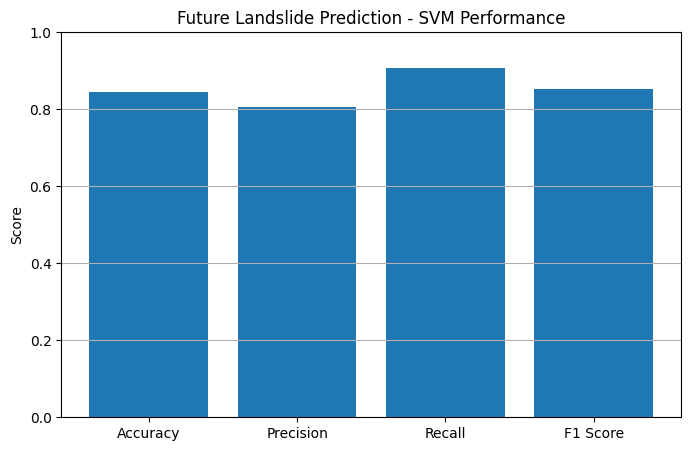

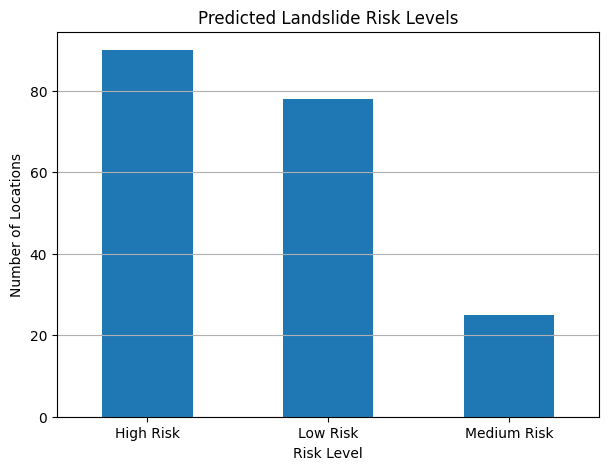

In [99]:
# Step 21: Visualize Future Landslide Prediction Results

import matplotlib.pyplot as plt

# -------------------------------
# 1. Model Performance
# -------------------------------

metrics = {
    "Accuracy": accuracy_future,
    "Precision": precision_future,
    "Recall": recall_future,
    "F1 Score": f1_future
}

plt.figure(figsize=(8, 5))

plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Future Landslide Prediction - SVM Performance")
plt.grid(axis="y")

plt.show()


# -------------------------------
# 2. Risk Level Distribution
# -------------------------------

plt.figure(figsize=(7, 5))

risk_results["Risk_Level"].value_counts().plot(
    kind="bar"
)

plt.title("Predicted Landslide Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Locations")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

In [100]:
# Step 23: Compare the Unit-2 classification models
# This comparison is used for Criterion 4:
# Comparative Performance Analysis

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Bayesian Logistic Regression"
    ],

    "Accuracy": [
        0.8208762886597938,
        accuracy_svm,
        accuracy_bayesian
    ],

    "Precision": [
        0.6037735849056604,
        precision_svm,
        precision_bayesian
    ],

    "Recall": [
        0.21333333333333335,
        recall_svm,
        recall_bayesian
    ],

    "F1 Score": [
        0.31527093596059114,
        f1_svm,
        f1_bayesian
    ]
})

# Round values for presentation
comparison_display = comparison.copy()

comparison_display[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
] = comparison_display[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].round(4)

display(comparison_display)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8209,0.6038,0.2133,0.3153
1,SVM,0.8402,0.7708,0.2467,0.3737
2,Bayesian Logistic Regression,0.8222,0.6111,0.2200,0.3235


In [101]:
# Step 24: Final Result Interpretation
# This cell summarizes the important results obtained
# from the machine learning experiments.

print("==============================================")
print("       PBL-1 FINAL RESULT SUMMARY")
print("==============================================")

print("\n1. DATASET")
print("----------------------------------------------")
print("Original dataset:", df.shape[0], "records")
print("Nepal landslide events:", len(nepal))

print("\n2. CLASSIFICATION MODELS")
print("----------------------------------------------")
print("Best Model: SVM")
print(f"SVM Accuracy : {accuracy_svm * 100:.2f}%")
print(f"SVM Precision: {precision_svm * 100:.2f}%")
print(f"SVM Recall   : {recall_svm * 100:.2f}%")
print(f"SVM F1 Score : {f1_svm * 100:.2f}%")

print("\n3. FUTURE LANDSLIDE PREDICTION")
print("----------------------------------------------")
print(f"Future SVM Accuracy : {accuracy_future * 100:.2f}%")
print(f"Future SVM Precision: {precision_future * 100:.2f}%")
print(f"Future SVM Recall   : {recall_future * 100:.2f}%")
print(f"Future SVM F1 Score : {f1_future * 100:.2f}%")

print("\n4. CONCLUSION")
print("----------------------------------------------")
print(
    "SVM achieved the best overall performance among "
    "the evaluated classification models."
)

print(
    "The environmental-feature model demonstrated the "
    "ability to distinguish historical landslide samples "
    "from background samples using rainfall, elevation, "
    "latitude and longitude."
)

print(
    "The future prediction system can provide a probability "
    "of landslide occurrence and classify the location into "
    "Low, Medium or High risk."
)

       PBL-1 FINAL RESULT SUMMARY

1. DATASET
----------------------------------------------
Original dataset: 11033 records
Nepal landslide events: 481

2. CLASSIFICATION MODELS
----------------------------------------------
Best Model: SVM
SVM Accuracy : 84.02%
SVM Precision: 77.08%
SVM Recall   : 24.67%
SVM F1 Score : 37.37%

3. FUTURE LANDSLIDE PREDICTION
----------------------------------------------
Future SVM Accuracy : 84.46%
Future SVM Precision: 80.56%
Future SVM Recall   : 90.62%
Future SVM F1 Score : 85.29%

4. CONCLUSION
----------------------------------------------
SVM achieved the best overall performance among the evaluated classification models.
The environmental-feature model demonstrated the ability to distinguish historical landslide samples from background samples using rainfall, elevation, latitude and longitude.
The future prediction system can provide a probability of landslide occurrence and classify the location into Low, Medium or High risk.


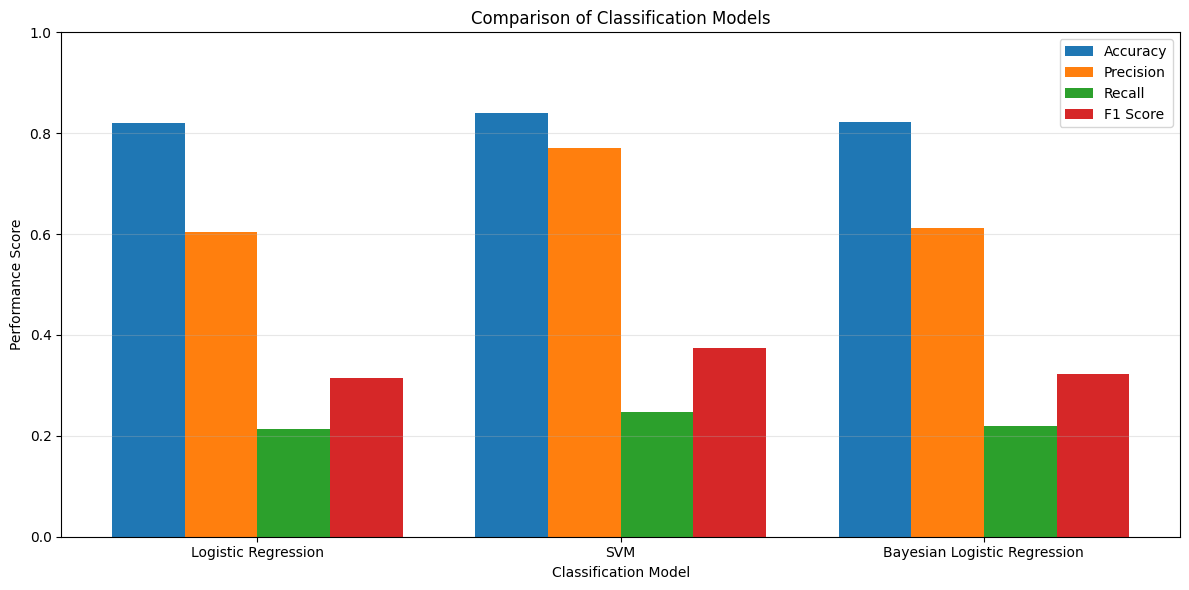

In [102]:
# Step 25: Graphical comparison of classification models
# This graph compares Accuracy, Precision, Recall and F1 Score.

import matplotlib.pyplot as plt
import numpy as np

models = [
    "Logistic Regression",
    "SVM",
    "Bayesian Logistic Regression"
]

accuracy = [
    0.8209,
    0.8402,
    0.8222
]

precision = [
    0.6038,
    0.7708,
    0.6111
]

recall = [
    0.2133,
    0.2467,
    0.2200
]

f1_score_values = [
    0.3153,
    0.3737,
    0.3235
]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12, 6))

plt.bar(x - 1.5 * width, accuracy, width, label="Accuracy")
plt.bar(x - 0.5 * width, precision, width, label="Precision")
plt.bar(x + 0.5 * width, recall, width, label="Recall")
plt.bar(x + 1.5 * width, f1_score_values, width, label="F1 Score")

plt.xlabel("Classification Model")
plt.ylabel("Performance Score")
plt.title("Comparison of Classification Models")

plt.xticks(x, models)
plt.ylim(0, 1)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()